In [1]:
import pandas as pd
import numpy as np

# 1. Читаем две основные таблицы (Pandas автоматически определит структуру)
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')

# 2. Фильтруем только доставленные заказы (Аналог WHERE order_status = 'delivered')
delivered_orders = orders[orders['order_status'] == 'delivered']

# 3. Объединяем таблицы по order_id (Аналог JOIN ... ON ...)
merged_df = pd.merge(delivered_orders, items, on='order_id')

# 4. Считаем базовые метрики бизнеса
total_revenue = merged_df['price'].sum()
total_freight = merged_df['freight_value'].sum()
orders_count = merged_df['order_id'].nunique() # Находим количество уникальных заказов
average_order_value = total_revenue / orders_count

# Выводим результаты
print(f"Общая выручка (Revenue): {total_revenue:,.2f} R$")
print(f"Затраты на доставку (Freight): {total_freight:,.2f} R$")
print(f"Количество доставленных заказов: {orders_count:,}")
print(f"Средний чек (AOV): {average_order_value:,.2f} R$")


Общая выручка (Revenue): 13,221,498.11 R$
Затраты на доставку (Freight): 2,198,275.64 R$
Количество доставленных заказов: 96,478
Средний чек (AOV): 137.04 R$


/var/folders/h5/nn_z0fbd4099gxgkjqyqmtvr0000gn/T/ipykernel_68780/196046708.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='product_category_name_english', data=top_categories, palette='Blues_r')


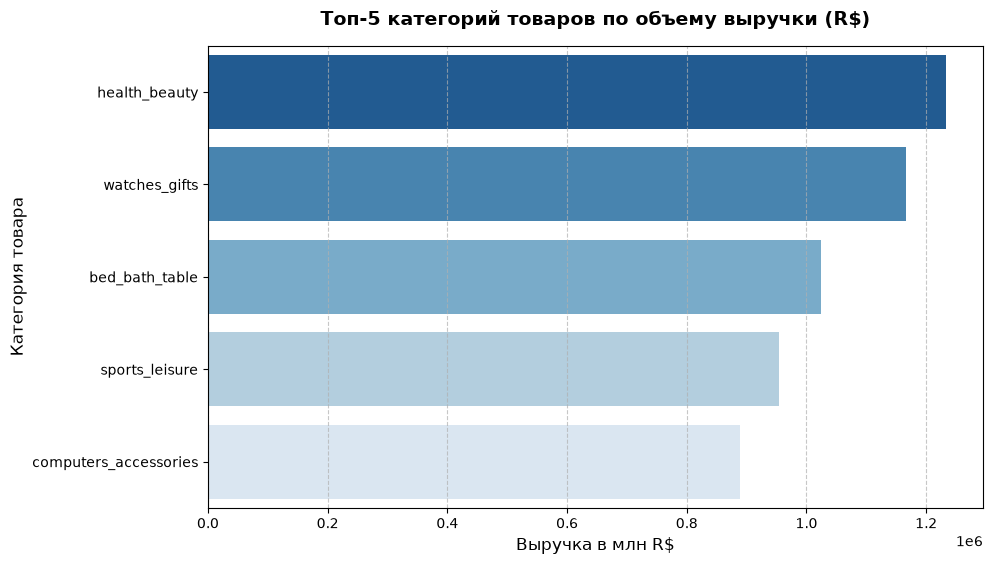

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Читаем таблицы продуктов и перевода категорий
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

# 2. Объединяем наши продажи с продуктами и переводником (Аналог множественного JOIN)
prod_df = pd.merge(merged_df, products, on='product_id')
prod_df = pd.merge(prod_df, translation, on='product_category_name')

# 3. Группируем по английскому названию и считаем выручку (Топ-5)
top_categories = prod_df.groupby('product_category_name_english')['price'].sum().reset_index()
top_categories = top_categories.sort_values(by='price', ascending=False).head(5)

# 4. Строим красивый график с помощью Seaborn и Matplotlib
plt.figure(figsize=(10, 6))
sns.barplot(x='price', y='product_category_name_english', data=top_categories, palette='Blues_r')

# Добавляем лоск: заголовки и подписи
plt.title('Топ-5 категорий товаров по объему выручки (R$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Выручка в млн R$', fontsize=12)
plt.ylabel('Категория товара', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Показываем график прямо в блокноте
plt.show()


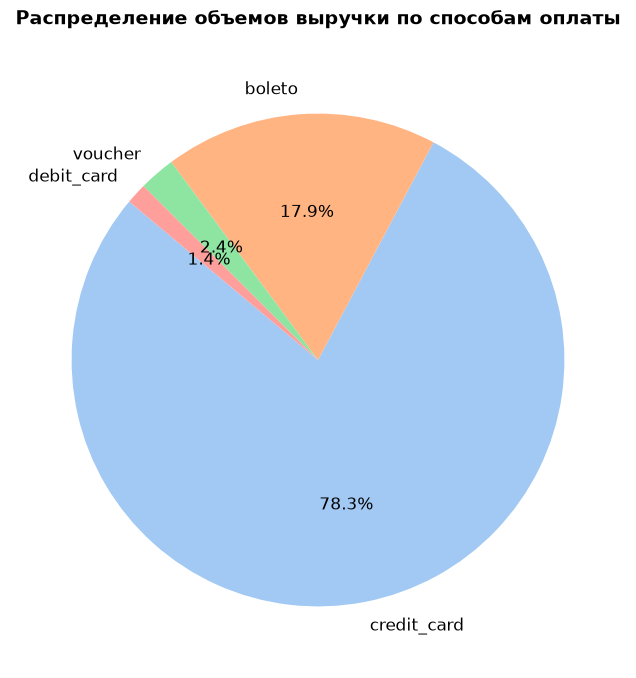

In [4]:
# 1. Читаем таблицу платежей по точному пути
payments = pd.read_csv('olist_order_payments_dataset.csv')

# 2. Группируем по типу оплаты и считаем общую сумму
pay_df = payments.groupby('payment_type')['payment_value'].sum().reset_index()
# Отсекаем неопределенные платежи (not_defined), если они есть, чтобы не портить график
pay_df = pay_df[pay_df['payment_type'] != 'not_defined'].sort_values(by='payment_value', ascending=False)

# 3. Строим красивую круговую диаграмму (Pie Chart)
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:5] # берем красивую пастельную палитру

plt.pie(
    pay_df['payment_value'], 
    labels=pay_df['payment_type'], 
    colors=colors, 
    autopct='%1.1f%%', # автоматически показывает проценты на графике
    startangle=140, 
    textprops={'fontsize': 12}
)

# Добавляем заголовок
plt.title('Распределение объемов выручки по способам оплаты', fontsize=14, fontweight='bold', pad=20)

# Показываем график
plt.show()
